In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df = pd.read_csv("1-studyhours.csv")

In [3]:
df.head()

,Study Hours,Exam Score
0,3.9,40.0
1,9.6,57.1
2,4.5,42.7
3,11.4,65.1
4,14.4,78.7


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33 entries, 0 to 32
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Study Hours  33 non-null     float64
 1   Exam Score   33 non-null     float64
dtypes: float64(2)
memory usage: 660.0 bytes


In [5]:
df.describe()

,Study Hours,Exam Score
count,33.000000,33.000000
mean,15.772727,74.612121
std,7.608723,18.711206
min,3.000000,40.000000
25%,9.600000,58.500000
50%,17.400000,78.800000
75%,21.300000,90.800000
max,30.000000,100.000000


Text(0, 0.5, 'Exam Score')

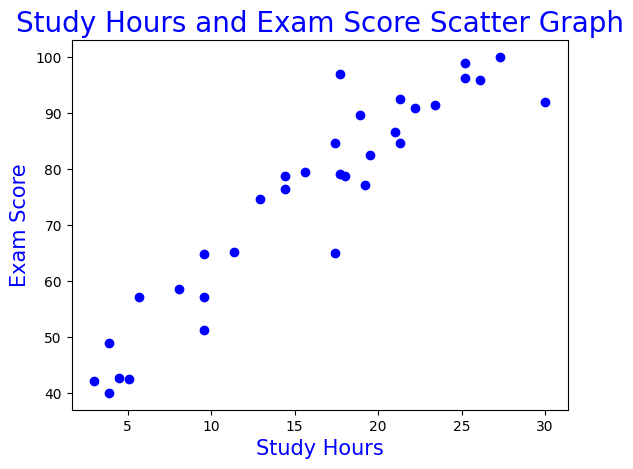

In [6]:
plt.scatter("Study Hours", "Exam Score", data=df, color = "blue")
plt.title("Study Hours and Exam Score Scatter Graph", fontsize = 20, color = "blue")
plt.xlabel("Study Hours", fontsize = 15, color = "blue")
plt.ylabel("Exam Score", fontsize = 15, color = "blue")

In [7]:
# independent (X) and dependent (y) features

X = df[['Study Hours']]
y = df[["Exam Score"]]

In [8]:
type(X)

pandas.core.frame.DataFrame

In [9]:
type(y)

pandas.core.frame.DataFrame

In [10]:
# test - train split

In [11]:
from sklearn.model_selection import train_test_split #important, chunk your mind!!!

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 15)

In [13]:
y_train

,Exam Score
18,64.9
1,57.1
2,42.7
32,89.6
6,77.1
3,65.1
29,82.4
26,64.8
9,84.6
4,78.7


In [14]:
y_test

,Exam Score
25,42.4
14,86.6
30,91.5
16,57.2
24,51.2
20,49.0
19,84.7


In [15]:
# Standardization : standardize the data set

In [16]:
from sklearn.preprocessing import StandardScaler

In [17]:
df.head()

,Study Hours,Exam Score
0,3.9,40.0
1,9.6,57.1
2,4.5,42.7
3,11.4,65.1
4,14.4,78.7


In [18]:
# balanced feature values
# efficient gradient descent
#l1,l2

In [19]:
scaler = StandardScaler()

In [20]:
X_train

,Study Hours
18,17.4
1,9.6
2,4.5
32,18.9
6,19.2
3,11.4
29,19.5
26,9.6
9,17.4
4,14.4


In [21]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test) # fit --> data leakage

In [22]:
X_train

array([[ 0.11794385],
       [-0.97424848],
       [-1.68837424],
       [ 0.32798083],
       [ 0.36998823],
       [-0.7222041 ],
       [ 0.41199563],
       [-0.97424848],
       [ 0.11794385],
       [-0.30213013],
       [ 0.15995124],
       [ 0.66404001],
       [-0.13410054],
       [ 1.50418796],
       [-0.51216711],
       [ 0.15995124],
       [-0.30213013],
       [ 1.21013618],
       [ 1.33615837],
       [ 0.7900622 ],
       [-1.77238903],
       [-1.89841122],
       [ 0.20195864],
       [ 1.88225453],
       [-1.18428547],
       [ 1.21013618]])

In [23]:
X_test

array([[-1.60435944],
       [ 0.62203261],
       [ 0.95809179],
       [-1.52034465],
       [-0.97424848],
       [-1.77238903],
       [ 0.66404001]])

In [24]:
from sklearn.linear_model import LinearRegression

In [25]:
regression = LinearRegression() # njobs --> for be faster

In [26]:
regression.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [27]:
print("Coefficent : ", regression.coef_)
print("Intercept : " , regression.intercept_ )

Coefficent :  [[16.17860223]]
Intercept :  [76.90769231]


In [28]:
# y = 76.91 + 16.18 x

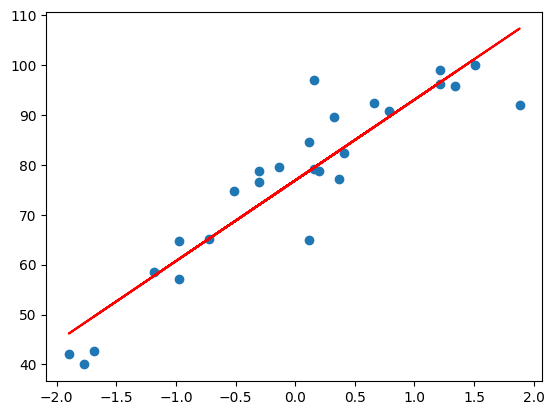

In [29]:
plt.scatter(X_train, y_train)
plt.plot(X_train, regression.predict(X_train), "r")
plt.show()

In [30]:
# x = 20, y = ?

In [31]:
regression.predict([[20]])

array([[400.47973694]])

In [32]:
scaler.transform([[20]])

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.48200796]])

In [33]:
regression.predict(scaler.transform([[20]]))

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[84.70590731]])

In [34]:
regression.predict(scaler.transform([[10]]))

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[62.05187491]])

In [35]:
regression.predict(scaler.transform([[0]]))

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[39.39784252]])

In [36]:
regression.predict(scaler.transform([[25]]))

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[96.0329235]])

In [37]:
# prediction with test data

In [38]:
y_pred_test = regression.predict(X_test)

In [39]:
y_test

,Exam Score
25,42.4
14,86.6
30,91.5
16,57.2
24,51.2
20,49.0
19,84.7


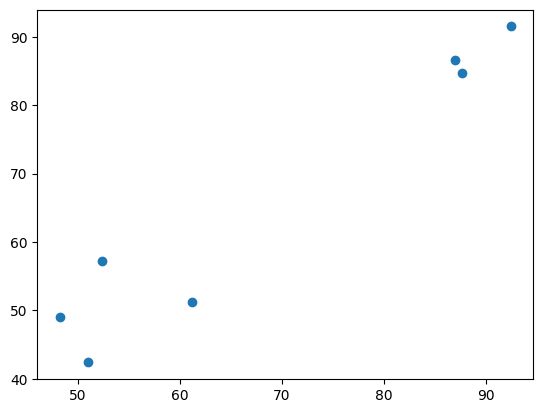

In [40]:
plt.scatter(y_pred_test, y_test)
plt.show()

In [41]:
from sklearn.metrics import mean_absolute_error , mean_squared_error, r2_score

In [42]:
mse = mean_squared_error(y_test, y_pred_test)
mae = mean_absolute_error(y_test, y_pred_test)
rmse = np.sqrt(mse)

print("mse : ", mse)
print("mae : ", mae)
print("rmse : ", rmse)

mse :  29.45839048833392
mae :  4.054868128856142
rmse :  5.427558427906043


In [43]:
# adjusted r2 score
r2 = r2_score(y_test, y_pred_test)
adjusted_r2_score = 1 - (1-r2) * (len(y_test)-1) / (len(y_test) - X_test.shape[1]-1)

In [44]:
adjusted_r2_score

0.903591544819059